In [2]:
import time
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

from fisherA2Z.fisher_flex import FisherFlex
from fisherA2Z import nz_decomposition as nzd

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

In [3]:
ALPHA_DIR = "fisher_flex_data/hscy1_alpha_sampling/alphas/"
ALPHA_FILES = [
    "result_photometry_0_3_0_6_alpha.dat",
    "result_photometry_0_6_0_9_alpha.dat",
    "alpha_result_0_9_1_2.dat",
    "alpha_result_1_2_1_5.dat",
]
BIN_LABELS = ["0.3 < z < 0.6", "0.6 < z < 0.9", "0.9 < z < 1.2", "1.2 < z < 1.5"]

N_REAL = 200                                 # realizations used to set the priors
z_grid = np.linspace(0.02, 3.0, 150)         # common grid; the alpha files stop at z < 2

rng = np.random.default_rng(42)
per_bin = []
for fname in ALPHA_FILES:
    alpha = np.loadtxt(ALPHA_DIR + fname)     # columns: z, alpha
    draws = rng.dirichlet(alpha[:, 1], size=N_REAL)
    draws /= np.trapz(draws, alpha[:, 0], axis=1)[:, None]
    # Each bin has its own z sampling, so interpolate onto the shared grid.
    on_grid = interp1d(alpha[:, 0], draws, kind="linear",
                       bounds_error=False, fill_value=0.0)(z_grid)
    on_grid = np.clip(on_grid, 0.0, None)
    per_bin.append(on_grid / np.trapz(on_grid, z_grid, axis=1)[:, None])

# FisherFlex wants (n_realizations, n_tomo, n_z).
nz_realizations = np.swapaxes(np.array(per_bin), 0, 1)
nz_source = nz_realizations.mean(axis=0)
nz_source /= np.trapz(nz_source, z_grid, axis=1)[:, None]

print("realizations:", nz_realizations.shape)
print("central n(z):", nz_source.shape)
print("mean redshift per bin:",
      np.round(np.trapz(nz_source * z_grid, z_grid, axis=1), 3))

realizations: (200, 4, 150)
central n(z): (4, 150)
mean redshift per bin: [0.464 0.745 1.048 1.325]


In [24]:
t0 = time.time()
flex_y1_cs = FisherFlex(
    # -- the n(z) and its uncertainty ---------------------------------
    nz_source=nz_source,
    nz_realizations=nz_realizations,
    z_grid=z_grid,
    # -- the survey ---------------------------------------------------
    neff_source=[2, 2, 1, 1],   # arcmin^-2, per tomographic bin
    fsky=0.5,                        # ~0.5
    sigma_e=0.26,                       # per-component ellipticity dispersion
    # -- the analysis -------------------------------------------------
    mode="cosmic_shear",                       # or '2x2pt' / 'cosmic_shear'
    nz_model="shift_stretch",           # the default; see below for the alternative
)
print(f"\n__init__ took {time.time() - t0:.1f} s")

flex_y1_cs.compute(parallel=True)

res_y1_cs = flex_y1_cs.forecast(ell_max_cs=1800, ell_min_cs=300)

s8, s8_err = res_y1_cs.s8()
print(f"LSSTY1 cosmic shear S_8 = {s8:.4f} +/- {s8_err:.4f}")


Measuring the shift and stretch of 200 realizations ...

__init__ took 0.1 s
Computing the fiducial data vector and covariance ...
Computing derivatives for 29 parameters (parallel) ...
Done.
LSSTY1 cosmic shear S_8 = 0.8523 +/- 0.0180


In [25]:
flex_y10_cs = FisherFlex(
    # -- the n(z) and its uncertainty ---------------------------------
    nz_source=nz_source,
    nz_realizations=nz_realizations,
    z_grid=z_grid,
    # -- the survey ---------------------------------------------------
    neff_source=[4, 5, 4, 2],   # arcmin^-2, per tomographic bin
    fsky=0.5,                        # ~0.5
    sigma_e=0.26,                       # per-component ellipticity dispersion
    # -- the analysis -------------------------------------------------
    mode="cosmic_shear",                       # or '2x2pt' / 'cosmic_shear'
    nz_model="shift_stretch",           # the default; see below for the alternative
)

flex_y10_cs.compute(parallel=True)

res_y10_cs = flex_y10_cs.forecast(ell_max_cs=1800, ell_min_cs=300)

s8, s8_err = res_y10_cs.s8()
print(f"LSSTY10 cosmic shear S_8 = {s8:.4f} +/- {s8_err:.4f}")


Measuring the shift and stretch of 200 realizations ...
Computing the fiducial data vector and covariance ...
Computing derivatives for 29 parameters (parallel) ...
Done.
LSSTY10 cosmic shear S_8 = 0.8523 +/- 0.0136


In [30]:
flex_y10_3x2pt = FisherFlex(
    # -- the n(z) and its uncertainty ---------------------------------
    nz_source=nz_source,
    nz_realizations=nz_realizations,
    z_grid=z_grid,
    # -- the survey ---------------------------------------------------
    neff_source=[4, 5, 4, 2],   # arcmin^-2, per tomographic bin
    fsky=0.5,                           # ~0.5
    sigma_e=0.26,                       # per-component ellipticity dispersion
    # -- the analysis -------------------------------------------------
    mode="3x2pt",                       # or '2x2pt' / 'cosmic_shear'
    nz_model="shift_stretch",           # the default; see below for the alternative
)

flex_y10_3x2pt.compute(parallel=True)

res_y10_3x2pt = flex_y10_3x2pt.forecast(ell_max_cs=1800, ell_min_cs=300)

s8, s8_err = res_y10_3x2pt.s8()
print(f"LSSTY10 3x2pt S_8 = {s8:.4f} +/- {s8_err:.4f}")



Measuring the shift and stretch of 200 realizations ...
Computing the fiducial data vector and covariance ...
Computing derivatives for 29 parameters (parallel) ...
Done.
LSSTY10 3x2pt S_8 = 0.8523 +/- 0.0037


In [32]:
# Individual probes, for comparison. `probes=` masks whole blocks out.
for label, kw in [("3x2pt", {"ell_max_cs": 1800, "ell_min_cs":300}),
                  ("cosmic shear only", {"probes": ["cs"],"ell_max_cs": 1800, "ell_min_cs":300}),
                  ("2x2pt (GGL + clustering)", {"probes": ["ggl", "gc"],"ell_max_cs": 1800, "ell_min_cs":300})]:
    r = flex_y10_3x2pt.forecast(**kw)
    print(f"{label:<26} n_data={r.n_data_used:>4}  "
          f"sigma(S8)={r.s8()[1]:.4f}  FoM(w0,wa)={r.fom('w_0', 'w_a'):8.2f}")

3x2pt                      n_data= 288  sigma(S8)=0.0037  FoM(w0,wa)=   35.78
cosmic shear only          n_data=  60  sigma(S8)=0.0136  FoM(w0,wa)=    4.09
2x2pt (GGL + clustering)   n_data= 228  sigma(S8)=0.0073  FoM(w0,wa)=   26.43


3x2pt                      n_data= 288  sigma(S8)=0.0037  FoM(w0,wa)=   35.78
2x2pt (GGL + clustering)   n_data= 228  sigma(S8)=0.0073  FoM(w0,wa)=   26.43


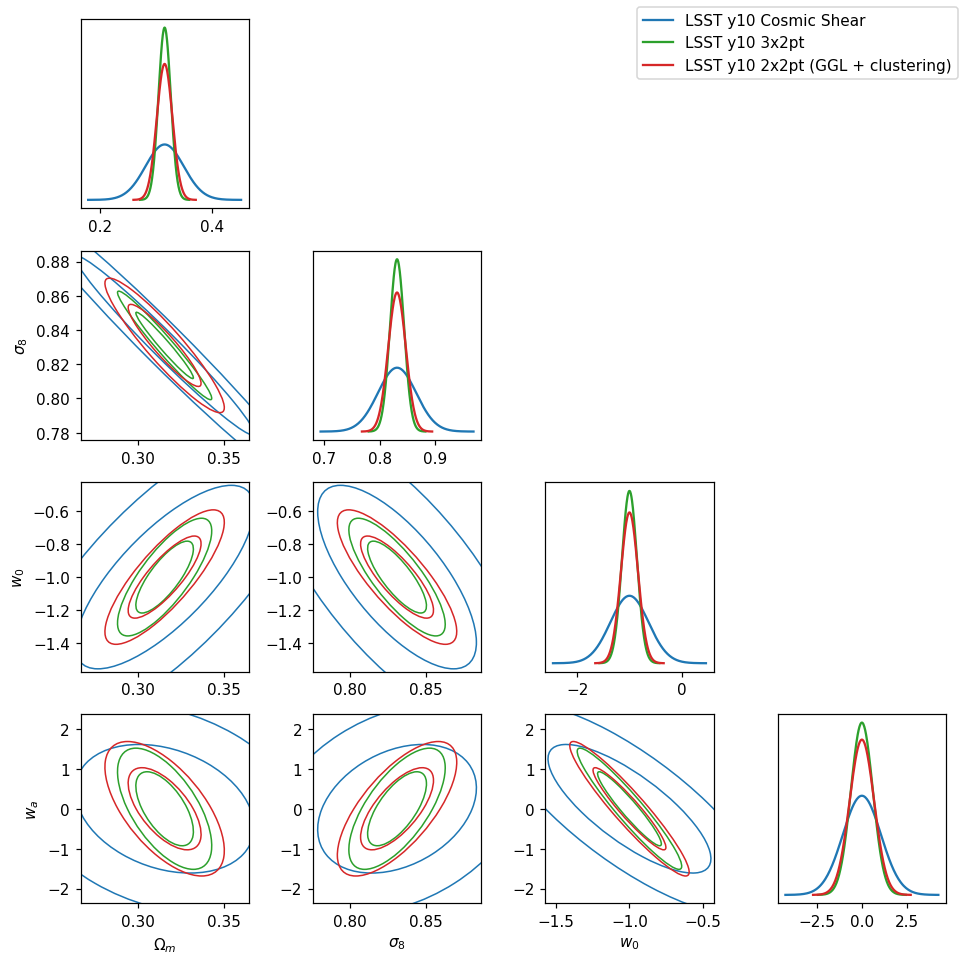

In [33]:
params = ["omega_m", "sigma_8", "w_0", "w_a"]
fig = res_y10_cs.corner(params, color="C0", label="LSST y10 Cosmic Shear")
# fig = res_y1_cs.corner(params, color="C1", label="LSST Y1 Cosmic Shear", fig = fig)
i=2
# Individual probes, for comparison. `probes=` masks whole blocks out.
for label, kw in [("3x2pt", {"ell_max_cs": 1800, "ell_min_cs":300}),
                  # ("cosmic shear only", {"probes": ["cs"],"ell_max_cs": 1800, "ell_min_cs":300}),
                  ("2x2pt (GGL + clustering)", {"probes": ["ggl", "gc"],"ell_max_cs": 1800, "ell_min_cs":300})]:
    r = flex_y10_3x2pt.forecast(**kw)
    print(f"{label:<26} n_data={r.n_data_used:>4}  "
          f"sigma(S8)={r.s8()[1]:.4f}  FoM(w0,wa)={r.fom('w_0', 'w_a'):8.2f}")

    fig = r.corner(params, color=f"C{i}", label=f"LSST y10 {label}", fig = fig)
    i+=1

fig.legend(loc="upper right", fontsize=10)
plt.show()